From the `Bamboo_setup` directory, run the following command:
```bash
jupyter notebook --no-browser --port=8888
```
Copy the URL starting with `http://localhost:8888/`.
When picking the kernel for this notebook, click **Existing Jupyter Server** and paste the URL.
Name your server 'localhost'.
From localhost, select the 'Python 3' kernel.

In [5]:
import sys
from pathlib import Path
BAMBOO_SETUP = Path.cwd()                                   
NEURALNET = BAMBOO_SETUP/'src'/'NeuralNet'                        
NOTEBOOKS = NEURALNET/'notebooks'                           
Z_OUTPUT_eos = Path('/eos/user/a/anunezde/Z_OUTPUT_eos')    # <-- Edit as needed
sys.path.append(str((BAMBOO_SETUP/'src').resolve()))
import pandas as pd
pd.set_option('display.max_columns', None)  # Display all columns
pd.set_option('display.width', 1000)  # Set a larger width to fit the editor window
import logging
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### If any changes are made to the imported modules in this notebook, you must run this cell first to load the new changes (this will reload all modules)

In [14]:
%autoreload 2

# Set up a Data Handler (to load and preprocess all data)

In [2]:
from NeuralNet.DataHandler import DataHandler
datahandler = DataHandler(
    workdir=Z_OUTPUT_eos/'2022_even_0815/Reco',
    tree_name='SL_res_2b_x'
    # total_inputs= NEURALNET / 'input/vars40.txt'
)
total_df = datahandler.start()

Welcome to JupyROOT 6.30/02


Starting data handler ...

Loading data...

Data inspection ... 
	Duplicate events:
		Number of duplicate events found: 39203
	Negative genWeights:
		Number of events with negative genWeights: 5165
	Null Values (i.e NaN, None):
		No events with null values found.
	Additional checks on numeric features only:
		No events with inf values found.
		No events with values larger than abs(10000.0) found.

Preprocessing data ...
	Dropping exact duplicates if any ...
	Removing events with negative weights ...

Data inspection ... 
	Duplicate events:
		Number of duplicate events found: 39203
	Negative genWeights:
		Number of events with negative genWeights: 5165
	Null Values (i.e NaN, None):
		No events with null values found.
	Additional checks on numeric features only:
		No events with inf values found.
		No events with values larger than abs(10000.0) found.


# Set up your model config

In [3]:
from NeuralNet.utils import ModelConfig
model_config = ModelConfig(
    name='multi_HH_ttbar_tW',
    type='multi',
    categorization={"HH": ["HH_bbWW"], "ttbar": ["ttbar"], "tW": ["tW"]},
    training_weight_sf={"HH_bbWW": 1.0, "ttbar": 8.0, "tW": 4.0},
    input_vars='All',
    architecture='defined_here',
    residual_network=False,
    hiddenlayers=[
        {"type": 'Dense', "units": 16, "activation": 'relu', "act_regularizer": {'l2': 1e-4}, "dropout_rate": 0.4}
        # {"type": 'Dense', "units": 16, "activation": 'relu', "act_regularizer": {'l2': 1e-4}, "dropout_rate": 0.4},
        # {"type": 'Dense', "units": 16, "activation": 'relu', "act_regularizer": {'l2': 1e-4}, "dropout_rate": 0.4}
    ],
    outputlayers=[
        {"type": 'Dense', "units": 3, "kernel_initializer": 'normal', "activation": 'softmax', "act_regularizer": {'l2': 1e-4}, "name": 'output'}
    ],
    compiler={"optimizer": 'adam', "lr": 0.001, "loss": 'categorical_crossentropy'},
    fit={"batch_size": 1024, "epochs": 2, "validation_split": 0.25}
)

# Run DNN

Initializing model: multi_HH_ttbar_tW

Building model ...


Model: "multi_HH_ttbar_tW"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 52)]              0         
                                                                 
 normalization (Normalizati  (None, 52)                0         
 on)                                                             
                                                                 
 layer_0 (Dense)             (None, 16)                848       
                                                                 
 batch_normalization (Batch  (None, 16)                64        
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 16)                0         
                                                                 
 output (Dense)              (None, 3)           


Training model ...


Epoch 1/2
729/729 [==============================] - 4s 3ms/step - loss: 11.3399 - accuracy: 0.8169 - precision: 0.9071 - recall: 0.5773 - auc_roc: 0.9231 - auc_pr: 0.8548 - f1_score_macro: 0.3575 - f1_score_micro: 0.8169 - precision_HH: 0.0155 - recall_HH: 0.0576 - precision_ttbar: 0.9563 - recall_ttbar: 0.6041 - precision_tW: 0.1901 - recall_tW: 0.1282 - val_loss: 9.9879 - val_accuracy: 0.9054 - val_precision: 0.9262 - val_recall: 0.8559 - val_auc_roc: 0.9680 - val_auc_pr: 0.9227 - val_f1_score_macro: 0.3937 - val_f1_score_micro: 0.9054 - val_precision_HH: 0.0243 - val_recall_HH: 0.0820 - val_precision_ttbar: 0.9550 - val_recall_ttbar: 0.8981 - val_precision_tW: 0.2429 - val_recall_tW: 0.1495 - lr: 0.0010
Epoch 2/2
729/729 [==============================] - 2s 3ms/step - loss: 10.0976 - accuracy: 0.8897 - precision: 0.9101 - recall: 0.8381 - auc_roc: 0.9608 - auc_pr: 0.9061 - f1_score_macro: 0.3854 - f1_score_micro: 0.8897 - precision_HH: 0.0187 - recall_HH: 0.1331 - precision_ttbar:


Evaluating model ...
	Model metrics: {'loss': 0.49635863304138184, 'accuracy': 0.9066166281700134, 'precision': 0.9209702610969543, 'recall': 0.8688859939575195, 'auc_roc': 0.9690200686454773, 'auc_pr': 0.9216437935829163, 'f1_score_macro': 0.40033650398254395, 'f1_score_micro': 0.9066166281700134, 'precision_HH': 0.053113553673028946, 'recall_HH': 0.15675675868988037, 'precision_ttbar': 0.9550684094429016, 'recall_ttbar': 0.9105654358863831, 'precision_tW': 0.2267611026763916, 'recall_tW': 0.1694214940071106}

Predicting ...


7770/7770 [==============================] - 6s 730us/step


({'loss': 0.49635863304138184,
  'accuracy': 0.9066166281700134,
  'precision': 0.9209702610969543,
  'recall': 0.8688859939575195,
  'auc_roc': 0.9690200686454773,
  'auc_pr': 0.9216437935829163,
  'f1_score_macro': 0.40033650398254395,
  'f1_score_micro': 0.9066166281700134,
  'precision_HH': 0.053113553673028946,
  'recall_HH': 0.15675675868988037,
  'precision_ttbar': 0.9550684094429016,
  'recall_ttbar': 0.9105654358863831,
  'precision_tW': 0.2267611026763916,
  'recall_tW': 0.1694214940071106},
 array([[0.23243243, 0.68648649, 0.08108108],
        [0.00680156, 0.94839592, 0.04480252],
        [0.01681891, 0.77823691, 0.20494418]]),
 array([[2.29823624e-02, 5.44118592e-04, 1.12317484e-03],
        [8.53019776e-01, 9.53462865e-01, 7.87195807e-01],
        [1.23997862e-01, 4.59930164e-02, 2.11681018e-01]]),
 ['HH', 'ttbar', 'tW'])

2024-10-31 21:46:34.835073: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-31 21:46:34.853463: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


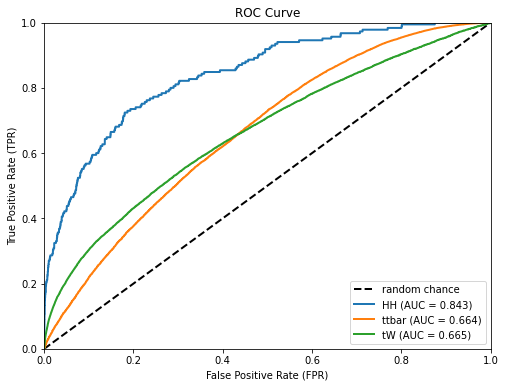

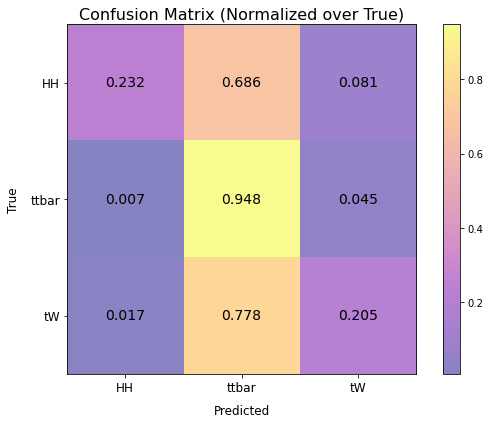

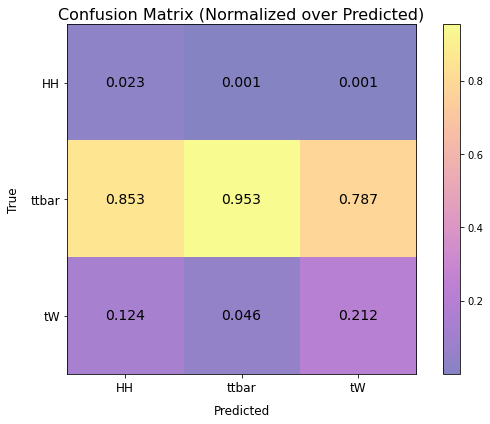

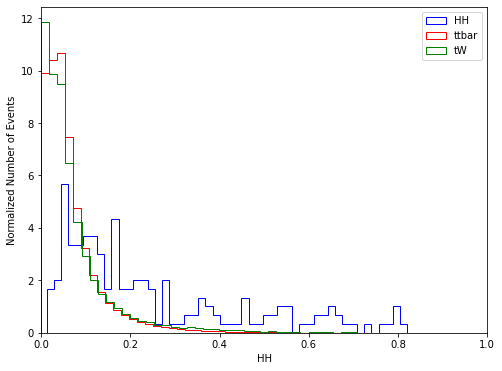

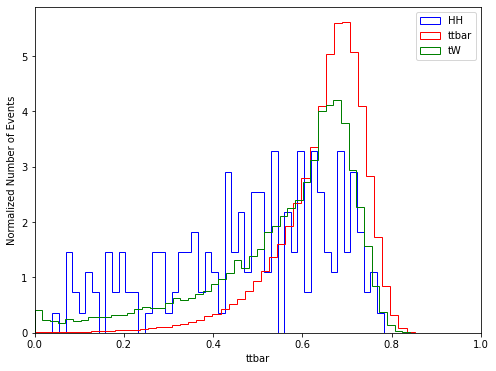

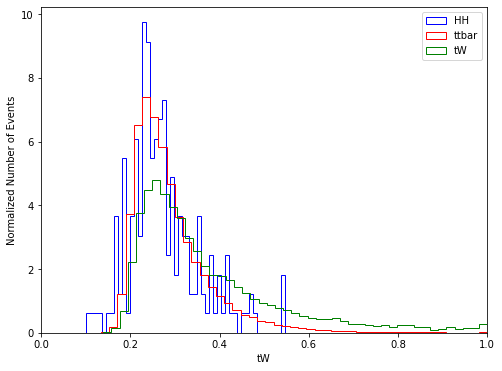

In [7]:
from NeuralNet.DNNModel import DNNModel
DNN = DNNModel(model_config=model_config, modeldir= NOTEBOOKS/'model_custom_trial')
DNN.Run(total_df, fixed_random_seed=True, save_model_info=False)